#**THINKING MODELS VS INSTRUCT MODELS**

####5 steps
We have done the projct in 5 steps
1. Load API keys
2. Create model clients
3. Define model functions
4. Run evaluation
5. Show results (UI / scorecard)

In [1]:
!pip install openai pandas matplotlib datasets python-dotenv

In [2]:
import os
import time
import json
import math
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

from openai import OpenAI
from google.colab import userdata

from dotenv import load_dotenv
load_dotenv()

True

####Loading the APIs

In [ ]:
openai_key = os.getenv("OPENAI_API_KEY")# for o3-mini
groq_key = os.getenv("GROQ_API_KEY")#for Llama models


print(openai_key[5:10], "...")  # just to confirm weather the apis loaded or not

oj--Y ...


##Creating clients

In [ ]:
openai_client = OpenAI(api_key=openai_key)

groq_client = OpenAI(
    api_key=groq_key,
    base_url="https://api.groq.com/openai/v1"
)

##Creating Model Functions

Here we are performing
1. Start timer
2. Send request to model
3. Get response
4. Calculate time

    Return:
      i. Answer
      ii. Time Taken


####THINKING MODELS

##### O3-MINI

In [5]:
import time

def call_o3(prompt):
    try:
        start = time.time()

        response = openai_client.chat.completions.create(
            model="o3-mini",
            messages=[{"role": "user", "content": prompt}]
        )

        end = time.time()

        content = response.choices[0].message.content.strip() if response.choices else ""

        # Handling empty response
        if not content:
            return {
                "response": "Error: Empty response",
                "time": end - start,
                "reasoning_quality": 0
            }


        reasoning_score = 5 if len(content) > 50 else 2

        return {
            "response": content,
            "time": end - start,
            "reasoning_quality": reasoning_score
        }

    except Exception as e:
        return {
            "response": f"Error: {e}",
            "time": 0,
            "reasoning_quality": 0
        }

##### qwen/qwen3-32b

In [6]:
import time

def call_qwen32b(prompt):
    try:
        start = time.time()

        response = together_client.chat.completions.create(
            model="qwen/qwen3-32b",
            messages=[{"role": "user", "content": prompt}]
        )

        end = time.time()

        # Safe extraction
        content = response.choices[0].message.content.strip() if response.choices else ""

        if not content:
            return {
                "response": "Error: Empty response",
                "time": end - start,
                "reasoning_quality": 0
            }

        # Better reasoning scoring logic
        def reasoning_quality(text):
            text_lower = text.lower()
            if len(text) < 20:
                return 1
            elif any(word in text_lower for word in ["step", "because", "therefore", "solution"]):
                return 5
            else:
                return 3

        reasoning_score = reasoning_quality(content)

        return {
            "response": content,
            "time": end - start,
            "reasoning_quality": reasoning_score
        }

    except Exception as e:
        return {
            "response": f"Error: {e}",
            "time": 0,
            "reasoning_quality": 0
        }

####INSTRUCT MODELS

##### llama-3.3-70b-versatile

In [7]:
import time

def call_llama_70b(prompt):
    try:
        start = time.time()

        response = groq_client.chat.completions.create(
            model="llama3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}]
        )

        end = time.time()

        # Safe extraction
        content = response.choices[0].message.content.strip() if response.choices else ""

        if not content:
            return {
                "response": "Error: Empty response",
                "time": end - start,
                "reasoning_quality": None   # ❗ Not a thinking model
            }

        return {
            "response": content,
            "time": end - start,
            "reasoning_quality": None   # ❗ Always None for Llama
        }

    except Exception as e:
        return {
            "response": f"Error: {e}",
            "time": 0,
            "reasoning_quality": None
        }

##### llama3.1-8b-instant

In [8]:
import time

def call_llama_8b(prompt):
    try:
        start = time.time()

        response = groq_client.chat.completions.create(
            model="llama3.1-8b-instant",
            messages=[{"role": "user", "content": prompt}]
        )

        end = time.time()

        # Safe extraction
        content = response.choices[0].message.content.strip() if response.choices else ""

        if not content:
            return {
                "response": "Error: Empty response",
                "time": end - start,
                "reasoning_quality": None   # ❗ Not a thinking model
            }

        return {
            "response": content,
            "time": end - start,
            "reasoning_quality": None   # ❗ Always None
        }

    except Exception as e:
        return {
            "response": f"Error: {e}",
            "time": 0,
            "reasoning_quality": None
        }

##MODEL DICTIONARY

To Loop through models easily and also to allow Dynamic selection of models to enable scalable evaluation

In [9]:
models = {
    "o3-mini": call_o3,
    "qwen-32b": call_qwen32b,
    "Llama-70B": call_llama_70b,
    "Llama-8B": call_llama_8b
}

#TASK 1
Math problems

##Loading the dataset

from hugging face directly

In [10]:
from datasets import load_dataset
dataset = load_dataset("gsm8k", "main")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


##Extracting the answer

In [11]:
def extract_gsm8k_answer(ans):
    return ans.split("####")[-1].strip()

def safe_float(x):
    try:
        return float(x)
    except:
        return None

## Preparing the data

In [12]:
math_questions = []

for i in range(100):
    item = dataset["train"][i]

    math_questions.append({
        "q": item["question"],
        "answer": safe_float(extract_gsm8k_answer(item["answer"]))
    })

math_questions[35:50]

[{'q': 'Mr. Sanchez found out that 40% of his Grade 5  students got a final grade below B. How many of his students got a final grade of B and above if he has 60 students in Grade 5?',
  'answer': 36.0},
 {'q': 'Lisa, Jack, and Tommy earned $60 from washing cars all week. However, half of the $60 was earned by Lisa. Tommy earned half of what Lisa earned. How much more money did Lisa earn than Tommy?',
  'answer': 15.0},
 {'q': 'Five friends eat at a fast-food chain and order the following: 5 pieces of hamburger that cost $3 each; 4 sets of French fries that cost $1.20; 5 cups of soda that cost $0.5 each; and 1 platter of spaghetti that cost $2.7. How much will each of them pay if they will split the bill equally?',
  'answer': 5.0},
 {'q': 'Artemis is making tea for a party. She knows her mom drinks an 8-ounce cup of tea and uses one ounce of tea. She will use this same ratio for the party. The party has 12 people there and each of them wants a 6-ounce cup of tea. How many ounces of te

##Manually checking the Models

In [13]:
#Using Langchain
#!pip install langchain langgraph langchain-core langchain-community langchain-openai langchain-groq

In [14]:
questions = [
    {'q': 'Samantha’s last name has three fewer letters than Bobbie’s last name. If Bobbie took two letters off her last name, she would have a last name twice the length of Jamie’s. Jamie’s full name is Jamie Grey. How many letters are in Samantha’s last name?', 'answer': '7'},
    {'q': 'Mark has a garden with flowers. He planted plants of three different colors in it. Ten of them are yellow, and there are 80% more of those in purple. There are only 25% as many green flowers as there are yellow and purple flowers. How many flowers does Mark have in his garden?', 'answer': '35'},
    {'q': 'Bella bought stamps at the post office. Some of the stamps had a snowflake design, some had a truck design, and some had a rose design. Bella bought 11 snowflake stamps. She bought 9 more truck stamps than snowflake stamps, and 13 fewer rose stamps than truck stamps. How many stamps did Bella buy in all?', 'answer': '65'},
    {'q': 'It takes Roque two hours to walk to work and one hour to ride his bike to work. Roque walks to and from work three times a week and rides his bike to and from work twice a week. How many hours in total does he take to get to and from work a week with walking and biking?', 'answer': '16'},
    {'q': 'In a truck, there are 26 pink hard hats, 15 green hard hats, and 24 yellow hard hats.  If Carl takes away 4 pink hard hats, and John takes away 6 pink hard hats and twice as many green hard hats as the number of pink hard hats that he removed, then calculate the total number of hard hats that remained in the truck.', 'answer': '43'},
    {'q': 'Mary does her grocery shopping on Saturday. She does her shopping only at a specific store where she is allowed a credit of $100, which must be paid in full before her next shopping trip. That week she spent the full credit limit and paid $15 of it on Tuesday and $23 of it on Thursday. How much credit will Mary need to pay before her next shopping trip?', 'answer': '62'},
    {'q': "Ann's favorite store was having a summer clearance. For $75 she bought 5 pairs of shorts for $7 each and 2 pairs of shoes for $10 each. She also bought 4 tops, all at the same price. How much did each top cost?", 'answer': '5'},
    {'q': 'Tim rides his bike back and forth to work for each of his 5 workdays.  His work is 20 miles away.  He also goes for a weekend bike ride of 200 miles.    If he can bike at 25 mph how much time does he spend biking a week?', 'answer': '20'},
    {'q': 'The profit from a business transaction is shared among 2 business partners, Mike and Johnson in the ratio 2:5 respectively. If Johnson got $2500, how much will Mike have after spending some of his share on a shirt that costs $200?', 'answer': '800'},
    {'q': 'A deep-sea monster rises from the waters once every hundred years to feast on a ship and sate its hunger. Over three hundred years, it has consumed 847 people. Ships have been built larger over time, so each new ship has twice as many people as the last ship. How many people were on the ship the monster ate in the first hundred years?', 'answer': '121'}
]

####Defining the Models for testing

In [15]:
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq

o3minillm = ChatOpenAI(model= 'o3-mini')
qwenllm = ChatGroq(model= 'qwen/qwen3-32b')
Lama8bllm = ChatGroq(model = "llama-3.1-8b-instant")
Lama70bllm = ChatGroq(model = "llama-3.3-70b-versatile")

#####Checking the models working

In [16]:
print(o3minillm.invoke("hello").content)

Hello there! How can I help you today?


In [17]:
print(qwenllm.invoke("hello").content)

<think>
Okay, the user said "hello". I need to respond appropriately. Since this is the first message, I should greet them back and offer help. Let me check if there's any specific context or previous conversation. No, there isn't. So a general friendly response would be best. Maybe ask how I can assist them today. Keep it simple and open-ended.
</think>

Hello! How can I assist you today? 😊


In [18]:
print(Lama70bllm.invoke("hello").content)

Hello. How can I assist you today?


In [19]:
print(Lama8bllm.invoke("hello").content)

Hello. How can I assist you today?


####Creating the dictionary of models for testing

In [20]:
testmodels = {
    "o3-mini": o3minillm,
    "qwen-32b": qwenllm,
    "Llama-70B": Lama70bllm,
    "Llama-8B": Lama8bllm
}

####Creating helper functions for calculations

In [21]:
import re

def extract_number(text):
    nums = re.findall(r'-?\d+\.?\d*', text)
    return nums[-1] if nums else None


def answer_quality(text):
    if "error" in text.lower():
        return 1

    length = len(text)

    if length > 150:
        return 5
    elif length > 100:
        return 4
    elif length > 50:
        return 3
    elif length > 20:
        return 2
    else:
        return 1

####Evaluating the sample questions and generating the results

In [22]:
import time
import re

def extract_thinking_content(text):
    """Extracts content between <think> tags."""
    match = re.search(r'<think>(.*?)</think>', text, re.DOTALL)
    return match.group(1).strip() if match else None

results = []


thinking_model_identifiers = ["r1", "reasoner", "thinking", "distill-qwen", "distill-llama"]

for item in questions:
    question = item['q']
    actual = item['answer']

    for model_name, llm in testmodels.items():

        is_thinking_model = any(id in model_name.lower() for id in thinking_model_identifiers)

        try:
            start = time.time()
            response = llm.invoke(question)
            end = time.time()

            output = response.content
            latency = end - start

            if "error" in output.lower():
                predicted = None
                accuracy = 0
                aq_score = 1
                reasoning_q = 0
                cost = 0
            else:
                predicted = extract_number(output)
                accuracy = 1 if predicted == actual else 0
                aq_score = answer_quality(output)
                cost = 0


                if is_thinking_model:
                    thinking_block = extract_thinking_content(output)
                    if thinking_block:

                        reasoning_q = reasoning_quality(thinking_block)
                    else:

                        reasoning_q = 0
                else:

                    reasoning_q = "N/A"

        except Exception as e:
            output = f"Error: {e}"
            latency = 0
            predicted = None
            accuracy = 0
            aq_score = 1
            reasoning_q = 0
            cost = 0

        results.append({
            "model": model_name,
            "question": question,
            "response": output,
            "predicted": predicted,
            "actual": actual,
            "accuracy": accuracy,
            "response_time": latency,
            "answer_quality": aq_score,
            "reasoning_quality": reasoning_q, # Added new field
            "cost_per_query": cost
        })

####Creating the data frame

In [23]:
import pandas as pd

df = pd.DataFrame(results)
df.head()

,model,question,response,predicted,actual,accuracy,response_time,answer_quality,reasoning_quality,cost_per_query
0,o3-mini,Samantha’s last name has three fewer letters t...,Jamie’s last name “Grey” has 4 letters. If Bob...,7,7,1,4.200293,5,N/A,0
1,qwen-32b,Samantha’s last name has three fewer letters t...,"<think>\nOkay, let's try to figure out this pr...",4,7,0,4.145365,5,N/A,0
2,Llama-70B,Samantha’s last name has three fewer letters t...,## Step 1: Determine the number of letters in ...,7,7,1,0.563721,5,N/A,0
3,Llama-8B,Samantha’s last name has three fewer letters t...,To find out the number of letters in Samantha'...,7,7,1,0.787408,5,N/A,0
4,o3-mini,Mark has a garden with flowers. He planted pla...,Mark has 10 yellow flowers. Since there are 80...,35,35,1,3.260230,5,N/A,0


####Saving questions to excel

In [24]:
import pandas as pd

pivoted_df = df.pivot(
    index='question',
    columns='model',
    values = ['response','accuracy','response_time','answer_quality']
)

pivoted_df.columns = [f"{model}_{metric}" for metric, model in pivoted_df.columns]

pivoted_df = pivoted_df.reset_index()

pivoted_df.to_excel("testResults.xlsx",index=False)

print("Spreadsheet created with one row per question")

Spreadsheet created with one row per question


####Generating the score card

In [25]:
import pandas as pd
import numpy as np


thinking_models = ["DeepSeek-R1", "qwen-32b", "o3-mini"]


def is_thinking_model(model_name):
    return any(m.lower() in str(model_name).lower() for m in thinking_models)


def clean_reasoning_column(row):
    model = row['model']
    val = row['reasoning_quality']

    if is_thinking_model(model):

        return pd.to_numeric(val, errors='coerce') if pd.notna(val) else 0.0
    else:
        return np.nan

df['reasoning_quality'] = df.apply(clean_reasoning_column, axis=1)


def mean_reasoning(series):
    numeric_series = pd.to_numeric(series, errors='coerce')


    if numeric_series.notna().sum() == 0:
        return np.nan

    return numeric_series.mean()

scorecard = df.groupby("model").agg({
    "accuracy": "mean",
    "response_time": "mean",
    "answer_quality": "mean",
    "reasoning_quality": mean_reasoning,
    "cost_per_query": "mean",
    "question": "count"
}).rename(columns={
    "question": "total_queries",
    "reasoning_quality": "mean_reasoning_quality"
}).round(3)


def format_reasoning(row):
    if is_thinking_model(row.name):

        return row["mean_reasoning_quality"]
    else:
        return "N/A"

scorecard["mean_reasoning_quality"] = scorecard.apply(format_reasoning, axis=1)


scorecard

,accuracy,response_time,answer_quality,mean_reasoning_quality,cost_per_query,total_queries
model,,,,,,
Llama-70B,0.8,0.610,5.0,N/A,0.0,10
Llama-8B,0.5,0.539,5.0,N/A,0.0,10
o3-mini,0.6,3.273,5.0,NaN,0.0,10
qwen-32b,0.5,5.985,5.0,NaN,0.0,10


####Ploting the bar plots

Graph saved as 'llm_scorecard_comparison.png'


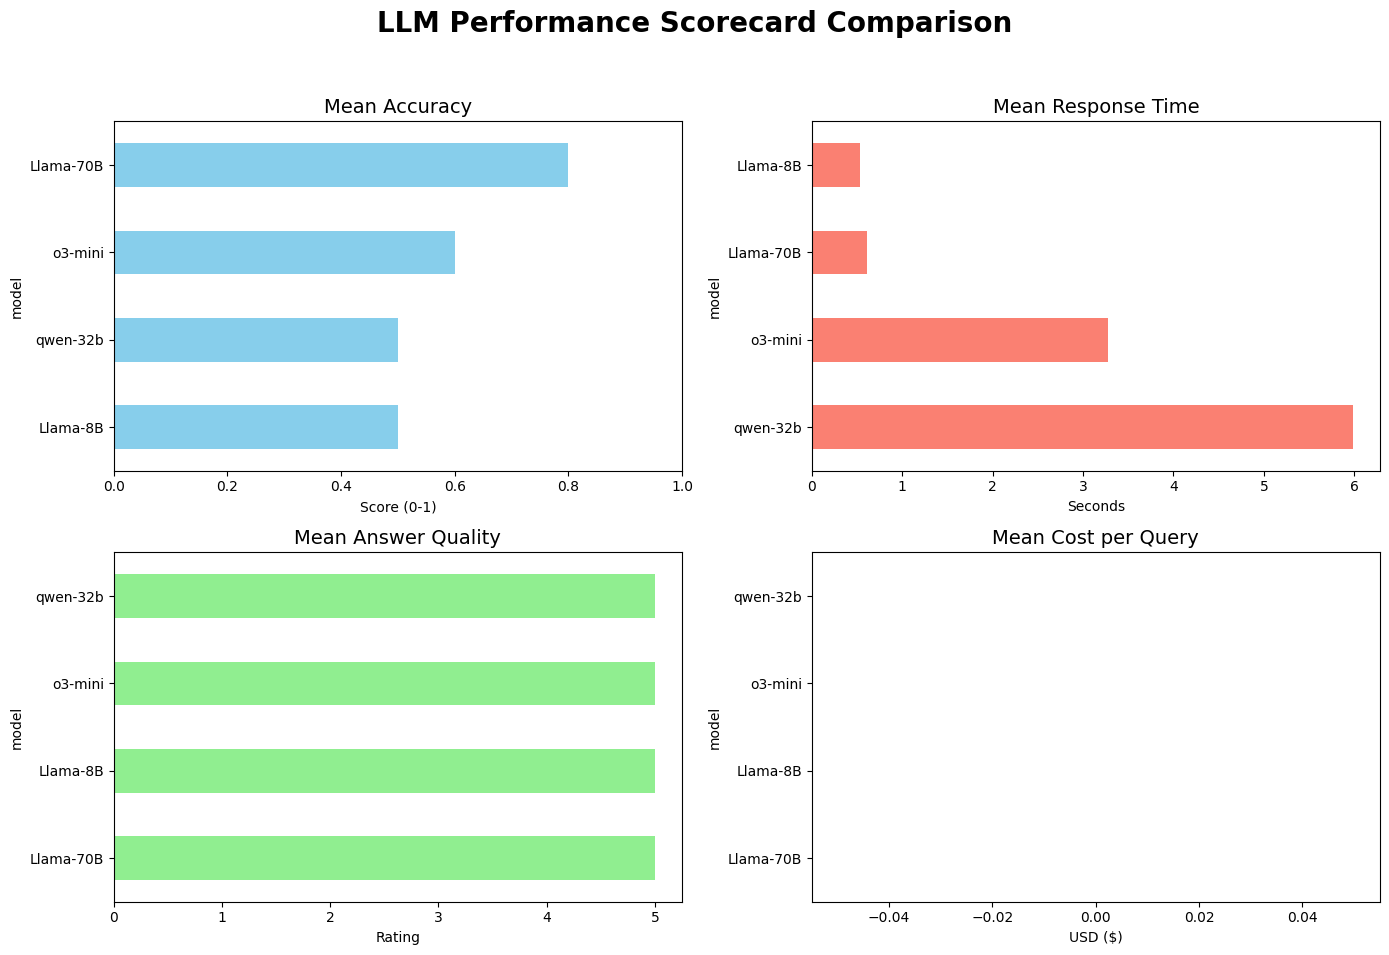

In [26]:
import matplotlib.pyplot as plt


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LLM Performance Scorecard Comparison', fontsize=20, fontweight='bold')

scorecard['accuracy'].sort_values().plot(kind='barh', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Mean Accuracy', fontsize=14)
axes[0, 0].set_xlim(0, 1.0)
axes[0, 0].set_xlabel('Score (0-1)')


scorecard['response_time'].sort_values(ascending=False).plot(kind='barh', ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Mean Response Time', fontsize=14)
axes[0, 1].set_xlabel('Seconds')

scorecard['answer_quality'].sort_values().plot(kind='barh', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Mean Answer Quality', fontsize=14)
axes[1, 0].set_xlabel('Rating')

scorecard['cost_per_query'].sort_values(ascending=False).plot(kind='barh', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Mean Cost per Query', fontsize=14)
axes[1, 1].set_xlabel('USD ($)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig('llm_scorecard_comparison.png')
print("Graph saved as 'llm_scorecard_comparison.png'")

##Helper function

In [27]:

def extract_number(text):
    if not text:
        return None

    text = text.replace(",", "").lower()

    match = re.search(r'(answer\s*[:=]\s*)(-?\d+\.?\d*)', text)
    if match:
        return float(match.group(2))

    match = re.search(r'(final.*?)(-?\d+\.?\d*)', text)
    if match:
        return float(match.group(2))

    nums = re.findall(r'-?\d+\.?\d*', text)
    return float(nums[-1]) if nums else None


def answer_quality(text):
    if not text:
        return 1

    text = text.lower()

    if "error" in text:
        return 1
    elif len(text) < 20:
        return 2
    elif any(w in text for w in ["step", "because", "therefore"]):
        return 5
    return 3

##Evaluation Loop

For Each question and model it will


1.   Sends the question
2.   Gets the Response
3.   Extract the Answer
4.   Checks the Correctness
5.   Stores the Result



In [28]:
final_results = []

for item in math_questions:
    question = item["q"]
    actual = item["answer"]

    for model_name, func in models.items():

        result = func(question)

        response = result["response"]
        t = result["time"]
        reasoning = result["reasoning_quality"]

        pred = extract_number(response)

        accuracy = (
            1 if (pred is not None and actual is not None and abs(pred - actual) < 1e-2)
            else 0
        )

        aq_score = answer_quality(response)

        final_results.append({
            "model": model_name,
            "question": question,
            "response": response,
            "predicted": pred,
            "actual": actual,
            "accuracy": accuracy,
            "response_time": t,
            "answer_quality": aq_score,
            "reasoning_quality": reasoning,
            "cost_per_query": 0
        })

##Creating the DataFrame

In [29]:
fdf = pd.DataFrame(final_results)
fdf.head()

,model,question,response,predicted,actual,accuracy,response_time,answer_quality,reasoning_quality,cost_per_query
0,o3-mini,Natalia sold clips to 48 of her friends in Apr...,"Natalia sold 48 clips in April. In May, she so...",72.0,72.0,1,2.84866,3,5.0,0
1,qwen-32b,Natalia sold clips to 48 of her friends in Apr...,Error: Error code: 402 - {'id': 'odtHNXK-2kFHo...,5.0,72.0,0,0.00000,1,0.0,0
2,Llama-70B,Natalia sold clips to 48 of her friends in Apr...,Error: Error code: 404 - {'error': {'message':...,-70.0,72.0,0,0.00000,1,NaN,0
3,Llama-8B,Natalia sold clips to 48 of her friends in Apr...,Error: Error code: 404 - {'error': {'message':...,-8.0,72.0,0,0.00000,1,NaN,0
4,o3-mini,Weng earns $12 an hour for babysitting. Yester...,"Weng works for 50 minutes, which is the same a...",10.0,10.0,1,3.38140,3,5.0,0


##Generating the scorecard

In [30]:
import pandas as pd
import numpy as np

thinking_models = ["qwen-32b", "o3-mini"]

def is_thinking_model(model):
    return any(m in model for m in thinking_models)

def mean_reasoning(series):
    return pd.to_numeric(series, errors="coerce").mean()

fscorecard = fdf.groupby("model").agg({
    "accuracy": "mean",
    "response_time": "mean",
    "answer_quality": "mean",
    "reasoning_quality": mean_reasoning,
    "cost_per_query": "mean",
    "question": "count"
}).rename(columns={
    "response_time": "avg_time",
    "question": "total_queries",
    "reasoning_quality": "mean_reasoning_quality"
}).round(3)

# Handle non-thinking models
fscorecard["mean_reasoning_quality"] = fscorecard.apply(
    lambda row: row["mean_reasoning_quality"] if is_thinking_model(row.name) else "N/A",
    axis=1
)

##Saving the results

In [31]:
fdf.to_csv("fresults.csv", index=False)
fscorecard.to_csv("fscorecard.csv")

##Graphs

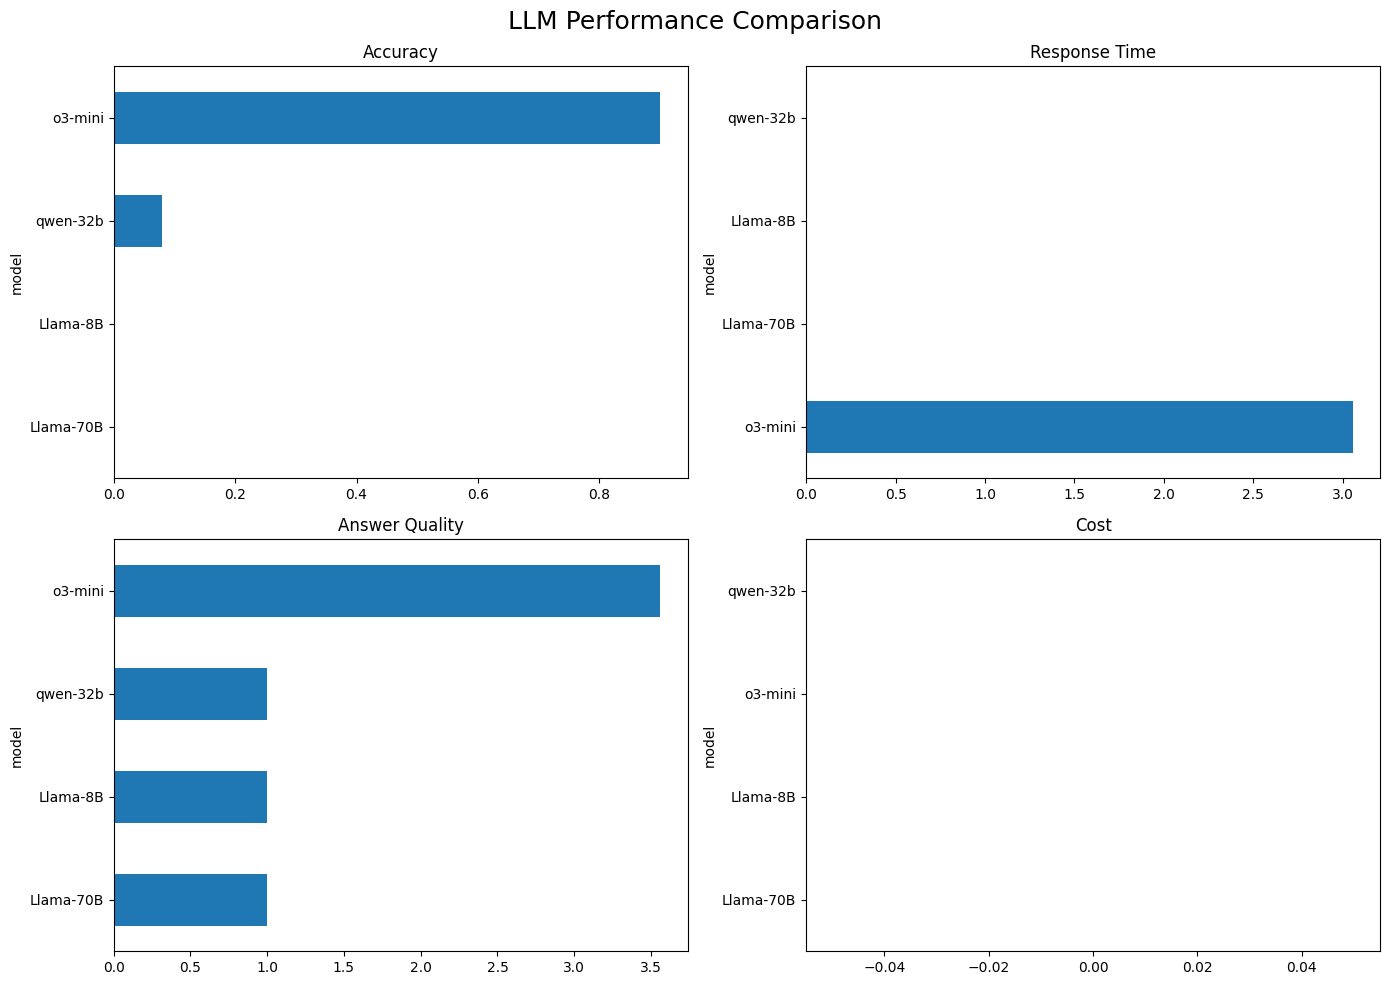

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LLM Performance Comparison', fontsize=18)

fscorecard['accuracy'].sort_values().plot(kind='barh', ax=axes[0, 0])
axes[0, 0].set_title('Accuracy')

fscorecard['avg_time'].sort_values(ascending=False).plot(kind='barh', ax=axes[0, 1])
axes[0, 1].set_title('Response Time')

fscorecard['answer_quality'].sort_values().plot(kind='barh', ax=axes[1, 0])
axes[1, 0].set_title('Answer Quality')

fscorecard['cost_per_query'].sort_values(ascending=False).plot(kind='barh', ax=axes[1, 1])
axes[1, 1].set_title('Cost')

plt.tight_layout()
plt.savefig("scorecard.png")
plt.show()

## Observations

- Models like o3-mini and qwen-32b perform better in math reasoning
- Models like Llama (8B/70B) struggle with multi-step problems

- Llama-8B → fastest
- o3-mini / qwen are slower but more accurate

- o3-mini → highest accuracy
- qwen-32b → close second
- Llama-70B → moderate
- Llama-8B → lowest

### Answer Quality vs Accuracy Mismatch

- Some models give long, detailed answers. But final answer is wrong

It shows that High answer quality ≠ high accuracy

### Reasoning Score Limitation

- Reasoning score is heuristic-based Not fully reliable

### Overall Conclusion

Reasoning-optimized models outperform general LLMs on structured problem-solving tasks, but at the cost of higher latency and computational overhead.